In [ ]:
!pip install geopandas shapely matplotlib

In [ ]:
import geopandas as gpd

In [ ]:
India =gpd.read_file("/content/drive/MyDrive/GBA/ADM/STATE_BOUNDARY.shp")

<Axes: >

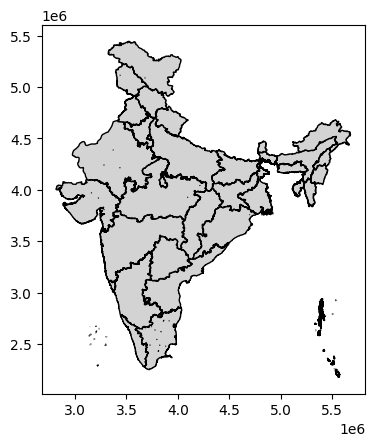

In [ ]:
India.plot(edgecolor="black",facecolor="lightgrey")

In [ ]:
data = {
    "city":['Pune','Mumbai','Chennai','Delhi','Bangalore', 'Kohima', 'Shillong', 'Ranchi', 'Thiruvananthapuram', 'Ludhiana'],
    "Latitude":[18.5204, 19.0760, 13.0827, 28.7041, 12.9716, 25.67, 25.57, 23.34, 8.485500, 30.9120],
    "Longitude":[73.8567, 72.8777, 80.2707, 77.1025, 77.5946, 94.11, 91.88, 85.04, 76.949240,75.8538]
}
geometry = [Point(xy)for xy in zip(data['Longitude'],data['Latitude'])]
gdf_points = gpd.GeoDataFrame(data,geometry=geometry)

In [ ]:
import geopandas as gpd
from shapely.geometry import Point,Polygon
import matplotlib.pyplot as plt

In [ ]:
geometry = [Point(xy)for xy in zip(data["Longitude"],data["Latitude"])]
gdf_points = gpd.GeoDataFrame(data,geometry=geometry)

In [ ]:
gdf_buffer = gdf_points.copy()
gdf_buffer['geometry']= gdf_buffer.buffer(5)

In [ ]:
BBOX = Polygon([(70,7),(70,32),(97,32),(97,7)])

In [ ]:
gdf_within_polygon = gdf_points[gdf_points.within(BBOX)]

In [ ]:
gdf_points['in polygon'] = gdf_points.geometry.apply(lambda x:BBOX.contains(x))

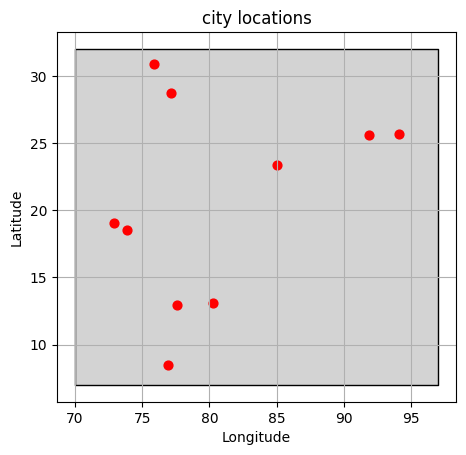

In [ ]:
fig, ax= plt.subplots()
gpd.GeoSeries([BBOX]).plot(ax=ax, color='lightgrey', edgecolor ='black')
gdf_points.plot(ax=ax, marker='o', color='red', markersize = 40)
plt.title("city locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [ ]:
print(gdf_points)

                 city  Latitude  Longitude                 geometry  \
0                Pune   18.5204   73.85670  POINT (73.8567 18.5204)   
1              Mumbai   19.0760   72.87770   POINT (72.8777 19.076)   
2             Chennai   13.0827   80.27070  POINT (80.2707 13.0827)   
3               Delhi   28.7041   77.10250  POINT (77.1025 28.7041)   
4           Bangalore   12.9716   77.59460  POINT (77.5946 12.9716)   
5              Kohima   25.6700   94.11000      POINT (94.11 25.67)   
6            Shillong   25.5700   91.88000      POINT (91.88 25.57)   
7              Ranchi   23.3400   85.04000      POINT (85.04 23.34)   
8  Thiruvananthapuram    8.4855   76.94924  POINT (76.94924 8.4855)   
9            Ludhiana   30.9120   75.85380   POINT (75.8538 30.912)   

   in polygon  
0        True  
1        True  
2        True  
3        True  
4        True  
5        True  
6        True  
7        True  
8        True  
9        True  


In [ ]:
print(gdf_buffer)

                 city  Latitude  Longitude  \
0                Pune   18.5204   73.85670   
1              Mumbai   19.0760   72.87770   
2             Chennai   13.0827   80.27070   
3               Delhi   28.7041   77.10250   
4           Bangalore   12.9716   77.59460   
5              Kohima   25.6700   94.11000   
6            Shillong   25.5700   91.88000   
7              Ranchi   23.3400   85.04000   
8  Thiruvananthapuram    8.4855   76.94924   
9            Ludhiana   30.9120   75.85380   

                                            geometry  
0  POLYGON ((78.8567 18.5204, 78.83262 18.03031, ...  
1  POLYGON ((77.8777 19.076, 77.85362 18.58591, 7...  
2  POLYGON ((85.2707 13.0827, 85.24662 12.59261, ...  
3  POLYGON ((82.1025 28.7041, 82.07842 28.21401, ...  
4  POLYGON ((82.5946 12.9716, 82.57052 12.48151, ...  
5  POLYGON ((99.11 25.67, 99.08592 25.17991, 99.0...  
6  POLYGON ((96.88 25.57, 96.85592 25.07991, 96.7...  
7  POLYGON ((90.04 23.34, 90.01592 22.84991, 89.9... 

In [ ]:
#Read and standardize columns
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

df_raw = pd.read_csv("/content/drive/MyDrive/GBA/earthquake_1995-2023.csv")
df_raw.columns = (
    df_raw.columns.astype(str).str.strip().str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_")
)
print("Rows and columns:", df_raw.shape)
print("Column names:", df_raw.columns.tolist())
display(df_raw.head())

Rows and columns: (1000, 19)
Column names: ['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'gap', 'magtype', 'depth', 'latitude', 'longitude', 'location', 'continent', 'country']


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magtype,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [ ]:
#Map to standard field names
aliases = {
    "latitude": ["latitude", "lat"],
    "longitude": ["longitude", "lon", "lng", "long"],
    "magnitude": ["magnitude", "mag"],
    "depth": ["depth", "depth_km"],
    "time": ["date_time", "datetime", "event_time", "time"],
    "place": ["location", "place", "region", "area"]
}
rename_map = {}
for standard_name, candidates in aliases.items():
    match = next((c for c in candidates if c in df_raw.columns), None)
    if match:
        rename_map[match] = standard_name

df = df_raw.rename(columns=rename_map).copy()
required = {"latitude", "longitude", "magnitude"}
missing = required.difference(df.columns)
if missing:
    raise ValueError(f"Required columns not found: {sorted(missing)}")
for optional in ["depth", "time", "place"]:
    if optional not in df.columns:
        df[optional] = np.nan if optional == "depth" else pd.NA
print("Mapped columns:", rename_map)

Mapped columns: {'latitude': 'latitude', 'longitude': 'longitude', 'magnitude': 'magnitude', 'depth': 'depth', 'date_time': 'time', 'location': 'place'}


In [ ]:
#Clean & audit
original_rows = len(df)

for col in ["latitude", "longitude", "magnitude", "depth"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# This dataset's date_time field is DD-MM-YYYY HH:MM
df["time"] = pd.to_datetime(df["time"], format="%d-%m-%Y %H:%M", errors="coerce", utc=True)

df["place"] = df["place"].fillna("Location not reported").astype(str)

df = df.dropna(subset=["latitude", "longitude", "magnitude"])
df = df[df["latitude"].between(-90, 90)]
df = df[df["longitude"].between(-180, 180)]
df = df[df["magnitude"].between(-2, 10.5)]

duplicate_fields = ["latitude", "longitude", "magnitude"]
if df["time"].notna().any():
    duplicate_fields.append("time")
df = df.drop_duplicates(subset=duplicate_fields).reset_index(drop=True)

clean_rows = len(df)
removed_rows = original_rows - clean_rows
print(f"Original rows: {original_rows:,}")
print(f"Clean rows: {clean_rows:,}")
print(f"Removed rows: {removed_rows:,} (duplicates only — no missing/invalid coordinates in this dataset)")
display(df[["latitude", "longitude", "magnitude", "depth", "time", "place"]].describe(include="all"))

Original rows: 1,000
Clean rows: 998
Removed rows: 2 (duplicates only — no missing/invalid coordinates in this dataset)


,latitude,longitude,magnitude,depth,time,place
count,998.000000,998.000000,998.000000,998.000000,998,998
unique,NaN,NaN,NaN,NaN,NaN,503
top,NaN,NaN,NaN,NaN,NaN,"Kokopo, Papua New Guinea"
freq,NaN,NaN,NaN,NaN,NaN,29
mean,4.219010,51.926244,6.940832,74.691925,2010-06-10 15:52:01.322645248+00:00,NaN
min,-61.848400,-179.968000,6.500000,2.700000,1995-05-05 03:53:00+00:00,NaN
25%,-13.553500,-71.668050,6.600000,16.000000,2003-08-08 12:30:45+00:00,NaN
50%,-2.484000,108.168500,6.800000,29.000000,2011-06-01 03:22:30+00:00,NaN
75%,24.776700,148.630250,7.100000,55.000000,2017-02-05 17:39:45+00:00,NaN
max,71.631200,179.662000,9.100000,670.810000,2023-08-16 12:47:00+00:00,NaN


In [ ]:
#Build GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

world_extent = box(-180, -90, 180, 90)
inside_world = gdf.geometry.apply(lambda geom: geom.within(world_extent) or geom.touches(world_extent))
gdf = gdf.loc[inside_world].copy()

assert gdf.crs.to_epsg() == 4326
assert gdf.geometry.geom_type.eq("Point").all()
assert gdf.geometry.is_valid.all()

print(gdf.crs)
print(gdf.geometry.geom_type.value_counts())
display(gdf.head())

EPSG:4326
Point    998
Name: count, dtype: int64


,title,magnitude,time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magtype,depth,latitude,longitude,place,continent,country,geometry
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00+00:00,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu,POINT (167.158 -13.8814)
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00+00:00,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN,POINT (-88.1265 12.814)
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00+00:00,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina,POINT (-70.3731 -38.1911)
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00+00:00,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN,POINT (-160.699 54.3844)
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00+00:00,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN,POINT (-160.796 54.49)


In [ ]:
#Magnitude Stats & Summary stats
mag_bins = [-np.inf, 2.9, 3.9, 4.9, 5.9, np.inf]
mag_labels = ["Below 3.0", "3.0–3.9", "4.0–4.9", "5.0–5.9", "6.0+"]
gdf["magnitude_class"] = pd.cut(gdf["magnitude"], bins=mag_bins, labels=mag_labels)

summary = {
    "event_count": len(gdf),
    "maximum_magnitude": gdf["magnitude"].max(),
    "mean_magnitude": gdf["magnitude"].mean(),
    "median_depth_km": gdf["depth"].median()
}
print(summary)
display(gdf["magnitude_class"].value_counts(sort=False))

{'event_count': 998, 'maximum_magnitude': 9.1, 'mean_magnitude': np.float64(6.940831663326654), 'median_depth_km': 29.0}


,count
magnitude_class,
Below 3.0,0
3.0–3.9,0
4.0–4.9,0
5.0–5.9,0
6.0+,998


In [ ]:
#Concentration Analysis
def concentration_at(gdf, grid_size):
    lat_min = (np.floor(gdf["latitude"] / grid_size) * grid_size).clip(-90, 90 - grid_size)
    lon_min = (np.floor(gdf["longitude"] / grid_size) * grid_size).clip(-180, 180 - grid_size)
    grid_stats = (
        gdf.assign(lat_min=lat_min, lon_min=lon_min)
        .groupby(["lat_min", "lon_min"], observed=True)
        .agg(event_count=("magnitude", "size"),
             mean_magnitude=("magnitude", "mean"),
             max_magnitude=("magnitude", "max"))
        .reset_index()
        .sort_values("event_count", ascending=False)
    )
    grid_stats["lat_center"] = grid_stats["lat_min"] + grid_size / 2
    grid_stats["lon_center"] = grid_stats["lon_min"] + grid_size / 2
    top = grid_stats.iloc[0]
    top_share = 100 * top["event_count"] / len(gdf)
    top5_share = 100 * grid_stats.head(5)["event_count"].sum() / len(gdf)
    return grid_stats, top, top_share, top5_share

GRID_SIZE = 10
grid_stats, top_cell, top_cell_share, top_five_share = concentration_at(gdf, GRID_SIZE)

top_cell_label = (
    f"{top_cell['lat_min']:.0f}° to {top_cell['lat_min'] + GRID_SIZE:.0f}° latitude; "
    f"{top_cell['lon_min']:.0f}° to {top_cell['lon_min'] + GRID_SIZE:.0f}° longitude"
)
print("Most active grid cell (10°):", top_cell_label)
print(f"Events in most active cell: {int(top_cell['event_count']):,}")
print(f"Share in most active cell: {top_cell_share:.2f}%")
print(f"Share in five most active cells: {top_five_share:.2f}%")

# Scale-sensitivity comparison
for gs in [5, 20]:
    _, t, share, share5 = concentration_at(gdf, gs)
    print(f"\nAt {gs}° grid: top cell share = {share:.2f}%, top-5 share = {share5:.2f}%")

display(grid_stats.head(10))

Most active grid cell (10°): -20° to -10° latitude; 160° to 170° longitude
Events in most active cell: 80
Share in most active cell: 8.02%
Share in five most active cells: 26.85%

At 5° grid: top cell share = 3.81%, top-5 share = 14.93%

At 20° grid: top cell share = 11.02%, top-5 share = 36.97%


,lat_min,lon_min,event_count,mean_magnitude,max_magnitude,lat_center,lon_center
27,-20.0,160.0,80,6.915000,8.00,-15.0,165.0
39,-10.0,150.0,78,6.912821,8.10,-5.0,155.0
45,0.0,120.0,43,6.906977,7.60,5.0,125.0
36,-10.0,120.0,34,6.947059,7.90,-5.0,125.0
85,30.0,140.0,33,6.975758,9.10,35.0,145.0
11,-40.0,-80.0,32,6.890625,8.80,-35.0,-75.0
38,-10.0,140.0,32,6.828125,7.60,-5.0,145.0
34,-10.0,100.0,27,7.055556,8.40,-5.0,105.0
49,10.0,-100.0,26,6.973077,8.20,15.0,-95.0
37,-10.0,130.0,24,6.970417,8.09,-5.0,135.0


In [ ]:
#Sample for plotting
MAX_BROWSER_POINTS = 25000
if len(gdf) > MAX_BROWSER_POINTS:
    plot_gdf = gdf.sample(MAX_BROWSER_POINTS, random_state=42).copy()
    sample_note = f"The globe displays a reproducible sample of {MAX_BROWSER_POINTS:,} events from {len(gdf):,} cleaned records."
else:
    plot_gdf = gdf.copy()
    sample_note = f"The globe displays all {len(gdf):,} cleaned events."

plot_gdf["time_label"] = plot_gdf["time"].dt.strftime("%Y-%m-%d %H:%M UTC").fillna("Time not reported")
plot_gdf["depth_label"] = plot_gdf["depth"].round(1).astype("string").fillna("Not reported")
print(sample_note)

The globe displays all 998 cleaned events.


In [ ]:
# Globe with events,hotspot layers & toggle buttons
event_custom = np.column_stack([plot_gdf["place"], plot_gdf["time_label"], plot_gdf["depth_label"]])

fig_globe = go.Figure()
fig_globe.add_trace(go.Scattergeo(
    lon=plot_gdf["longitude"], lat=plot_gdf["latitude"], mode="markers",
    name="Earthquake events", customdata=event_custom,
    marker=dict(
        size=np.clip(2.5 + (plot_gdf["magnitude"] - 2) * 1.25, 3, 12),
        color=plot_gdf["magnitude"], colorscale="Turbo",
        cmin=plot_gdf["magnitude"].quantile(0.02), cmax=plot_gdf["magnitude"].quantile(0.98),
        opacity=0.62, colorbar=dict(title="Magnitude", thickness=12)
    ),
    hovertemplate=("<b>%{customdata[0]}</b><br>Magnitude: %{marker.color:.1f}<br>"
                    "Depth (km): %{customdata[2]}<br>Time: %{customdata[1]}<br>"
                    "Lon: %{lon:.2f}, Lat: %{lat:.2f}<extra></extra>")
))

hotspots = grid_stats.head(30).copy()
fig_globe.add_trace(go.Scattergeo(
    lon=hotspots["lon_center"], lat=hotspots["lat_center"], mode="markers",
    name="Top concentration cells",
    customdata=np.column_stack([hotspots["event_count"], hotspots["mean_magnitude"], hotspots["max_magnitude"]]),
    marker=dict(size=np.clip(6 + 2.2 * np.sqrt(hotspots["event_count"]), 9, 48), sizemode="diameter",
                color="#FFB000", opacity=0.35, line=dict(color="#7A3E00", width=1)),
    hovertemplate=("<b>10° concentration cell</b><br>Events: %{customdata[0]:,.0f}<br>"
                    "Mean magnitude: %{customdata[1]:.2f}<br>Maximum magnitude: %{customdata[2]:.1f}<extra></extra>")
))

fig_globe.update_geos(projection_type="orthographic", showland=True, landcolor="#DCE7D8",
                       showocean=True, oceancolor="#DDEEFF", showlakes=True, lakecolor="#DDEEFF",
                       showcountries=True, countrycolor="#9AA7B2", coastlinecolor="#6B7785",
                       bgcolor="rgba(0,0,0,0)")
fig_globe.update_layout(
    title="Interactive 3D Earthquake Globe (1995–2023)", height=680, margin=dict(l=0, r=0, t=55, b=0),
    paper_bgcolor="white", legend=dict(orientation="h", y=0.02, x=0.02),
    updatemenus=[dict(type="buttons", direction="right", x=0.01, y=1.08, buttons=[
        dict(label="Events only", method="update", args=[{"visible": [True, False]}]),
        dict(label="Hotspots only", method="update", args=[{"visible": [False, True]}]),
        dict(label="Both layers", method="update", args=[{"visible": [True, True]}])
    ])]
)
fig_globe.show()

In [ ]:
#Supporting Charts
fig_magnitude = px.box(
    gdf.dropna(subset=["continent"]),
    x="continent", y="magnitude",
    title="Magnitude Distribution by Continent",
    labels={"continent": "Continent", "magnitude": "Magnitude"},
    color="continent"
)
fig_magnitude.update_layout(template="plotly_white", height=390, showlegend=False)
fig_magnitude.update_xaxes(tickangle=-30)

In [ ]:
globe_html = pio.to_html(fig_globe, full_html=False, include_plotlyjs="cdn",
                          config={"responsive": True, "displaylogo": False}, div_id="earthquake-globe")
magnitude_html = pio.to_html(fig_magnitude, full_html=False, include_plotlyjs=False,
                              config={"responsive": True, "displaylogo": False}, div_id="magnitude-chart")
time_html = pio.to_html(fig_time, full_html=False, include_plotlyjs=False,
                         config={"responsive": True, "displaylogo": False}, div_id="time-chart")

print("KPIs for your dashboard:")
print(summary)
print(f"Top cell: {top_cell_label}, share: {top_cell_share:.2f}%, top-5 share: {top_five_share:.2f}%")

with open("dashboard_components.txt", "w") as f:
    f.write("=== GLOBE ===\n" + globe_html + "\n\n=== MAGNITUDE CHART ===\n" + magnitude_html + "\n\n=== TIME CHART ===\n" + time_html)
from google.colab import files
files.download("dashboard_components.txt")

KPIs for your dashboard:
{'event_count': 998, 'maximum_magnitude': 9.1, 'mean_magnitude': np.float64(6.940831663326654), 'median_depth_km': 29.0}
Top cell: -20° to -10° latitude; 160° to 170° longitude, share: 8.02%, top-5 share: 26.85%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>